# Dataset Validation and Cross-Reference Analysis

Comprehensive validation of the Data in Brief dataset with file integrity, data validation, and HMA tissue matching.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

plt.style.use('default')
sns.set_palette('Set2')
primary_green = '#2E8B57'
print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
file_manifest = pd.read_csv('../results/dataset_validation/file_manifest.csv')
integrity_report = pd.read_csv('../results/dataset_validation/data_integrity_report.csv')
cross_reference = pd.read_csv('../results/dataset_validation/cross_reference_validation.csv')

hma_tissue_matching = pd.read_csv('../results/hma_matching/hma_tissue_matching.csv')
hma_tissue_summary = pd.read_csv('../results/hma_matching/hma_tissue_summary.csv')
hma_pseudo_stats = pd.read_csv('../results/hma_matching/hma_pseudo_label_stats.csv')

print('Validation data loaded successfully.')
print(f'File manifest: {file_manifest.shape[0]} files')
print(f'Integrity report: {integrity_report.shape[0]} checks')
print(f'HMA tissue matching: {hma_tissue_matching.shape[0]} patients')

Validation data loaded successfully.
File manifest: 16 files
Integrity report: 20 checks
HMA tissue matching: 219 patients


## File Manifest Summary

In [3]:
print('\n=== FILE MANIFEST ===')
print(f'Total files: {file_manifest.shape[0]}')
print(f'Total size: {file_manifest["size_bytes"].sum() / (1024*1024):.2f} MB')

categories = file_manifest['description'].value_counts()
print('\nFiles by category:')
for category, count in categories.items():
    print(f'  {category}: {count} files')

print('\nDetailed file listing:')
manifest_display = file_manifest[['filename', 'format', 'n_rows', 'n_cols', 'size_bytes']].copy()
manifest_display['size_KB'] = (manifest_display['size_bytes'] / 1024).round(1)
print(manifest_display[['filename', 'format', 'n_rows', 'n_cols', 'size_KB']].to_string(index=False))


=== FILE MANIFEST ===
Total files: 16
Total size: 0.14 MB

Files by category:
  Omics quality control statistics: 6 files
  Graph structure statistics: 4 files
  Patient demographic and clinical metadata: 3 files
  HMA tissue matching data: 3 files

Detailed file listing:
                               filename format  n_rows  n_cols  size_KB
                   patient_metadata.tsv    TSV     219      13     16.0
                   age_distribution.csv    CSV      12       3      0.3
                     cohort_summary.csv    CSV      21       3      0.7
                  rnaseq_gene_stats.csv    CSV     500       5     35.0
       proteomics_per_protein_stats.csv    CSV     500       5     35.9
              metabolomics_coverage.csv    CSV     222       6     16.3
           rnaseq_per_patient_stats.csv    CSV     219       5     15.0
proteomics_per_patient_completeness.csv    CSV     219       3      7.0
     omics_recon3d_coverage_summary.csv    CSV       3       4      0.2
      

## Data Integrity Report

In [4]:
print('\n=== DATA INTEGRITY VALIDATION ===')
pass_count = (integrity_report['status'] == 'PASS').sum()
fail_count = (integrity_report['status'] == 'FAIL').sum()
warn_count = (integrity_report['status'] == 'WARN').sum()

print(f'Total validation checks: {integrity_report.shape[0]}')
print(f'PASS: {pass_count}, FAIL: {fail_count}, WARN: {warn_count}')
print(f'\nValidation summary:')
for idx, row in integrity_report.head(10).iterrows():
    status_symbol = 'PASS' if row['status'] == 'PASS' else 'FAIL'
    print(f'{status_symbol}: {row["check_name"]}')


=== DATA INTEGRITY VALIDATION ===
Total validation checks: 20
PASS: 20, FAIL: 0, WARN: 0

Validation summary:
PASS: No NaN in patient_metadata
PASS: Patient ID uniqueness
PASS: Age range validation
PASS: Cohort distribution
PASS: Sex distribution
PASS: Stage distribution
PASS: MSI distribution
PASS: Metabolomics availability
PASS: OS data completeness
PASS: DFS data completeness


## HMA Tissue Matching Analysis

In [5]:
print('\n=== HMA TISSUE MATCHING ===')
print(f'Patients matched: {hma_tissue_matching.shape[0]}')
print(f'Unique tissues: {hma_tissue_matching["matched_tissue"].nunique()}')
print(f'\nMean cosine similarity: {hma_tissue_matching["cosine_similarity"].mean():.4f}')
print(f'Std cosine similarity: {hma_tissue_matching["cosine_similarity"].std():.4f}')
print(f'Mean active reactions: {hma_tissue_matching["n_active_reactions_in_tissue_model"].mean():.0f}')


=== HMA TISSUE MATCHING ===
Patients matched: 219
Unique tissues: 15

Mean cosine similarity: 0.7941
Std cosine similarity: 0.1147
Mean active reactions: 4139


## Figure 3: Dataset Validation and HMA Matching

/sessions/beautiful-dreamy-ride/tmp/ipykernel_2948/255031002.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


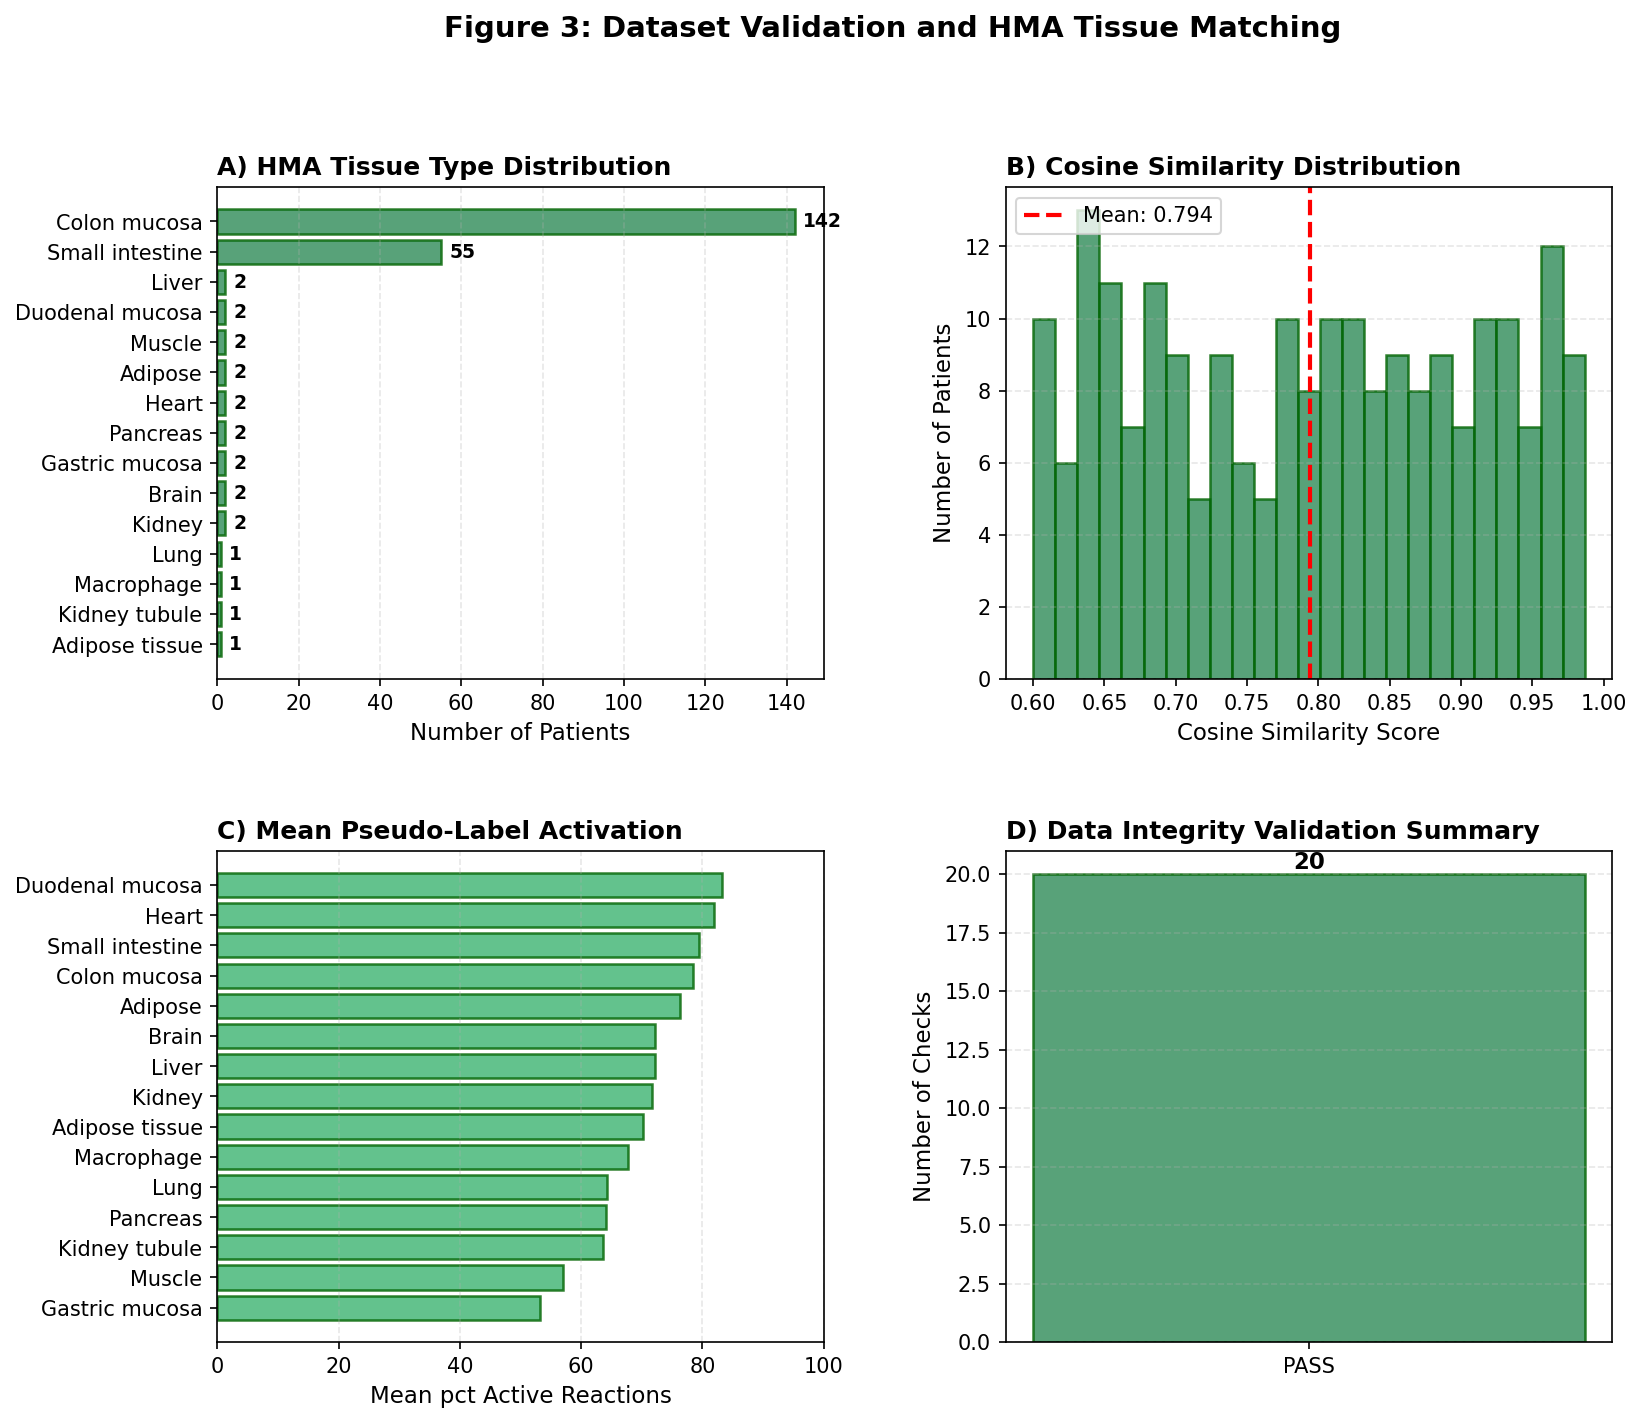

Figure 3 saved as Figure_3_Dataset_Validation.png


In [6]:
fig = plt.figure(figsize=(12, 10), dpi=150)
gs = GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

# Panel A: HMA tissue distribution
ax_a = fig.add_subplot(gs[0, 0])
tissue_dist = hma_tissue_summary.sort_values('n_patients', ascending=True)
bars = ax_a.barh(tissue_dist['tissue_type'], tissue_dist['n_patients'], color=primary_green, alpha=0.8, edgecolor='darkgreen', linewidth=1.2)
ax_a.set_title('A) HMA Tissue Type Distribution', fontsize=12, fontweight='bold', loc='left')
ax_a.set_xlabel('Number of Patients', fontsize=11)
ax_a.grid(axis='x', alpha=0.3, linestyle='--')
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax_a.text(width + 2, bar.get_y() + bar.get_height()/2, f'{int(width)}', ha='left', va='center', fontsize=9, fontweight='bold')

# Panel B: Cosine similarity distribution
ax_b = fig.add_subplot(gs[0, 1])
ax_b.hist(hma_tissue_matching['cosine_similarity'], bins=25, color=primary_green, alpha=0.8, edgecolor='darkgreen', linewidth=1.2)
ax_b.axvline(hma_tissue_matching['cosine_similarity'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {hma_tissue_matching["cosine_similarity"].mean():.3f}')
ax_b.set_title('B) Cosine Similarity Distribution', fontsize=12, fontweight='bold', loc='left')
ax_b.set_xlabel('Cosine Similarity Score', fontsize=11)
ax_b.set_ylabel('Number of Patients', fontsize=11)
ax_b.legend(fontsize=10, loc='upper left')
ax_b.grid(axis='y', alpha=0.3, linestyle='--')

# Panel C: Pseudo-label activation
ax_c = fig.add_subplot(gs[1, 0])
tissue_act = hma_pseudo_stats.sort_values('mean_across_patients', ascending=True)
bars_c = ax_c.barh(tissue_act['tissue_type'], tissue_act['mean_across_patients'], color='#3CB371', alpha=0.8, edgecolor='darkgreen', linewidth=1.2)
ax_c.set_title('C) Mean Pseudo-Label Activation', fontsize=12, fontweight='bold', loc='left')
ax_c.set_xlabel('Mean pct Active Reactions', fontsize=11)
ax_c.grid(axis='x', alpha=0.3, linestyle='--')
ax_c.set_xlim([0, 100])

# Panel D: Validation status
ax_d = fig.add_subplot(gs[1, 1])
status_counts = integrity_report['status'].value_counts()
status_order = ['PASS', 'FAIL', 'WARN']
status_colors = {'PASS': '#2E8B57', 'FAIL': '#DC143C', 'WARN': '#FFB347'}
statuses = [s for s in status_order if s in status_counts.index]
values = [status_counts[s] for s in statuses]
colors_status = [status_colors[s] for s in statuses]
bars_d = ax_d.bar(statuses, values, color=colors_status, alpha=0.8, edgecolor='darkgreen', linewidth=1.2)
ax_d.set_title('D) Data Integrity Validation Summary', fontsize=12, fontweight='bold', loc='left')
ax_d.set_ylabel('Number of Checks', fontsize=11)
ax_d.grid(axis='y', alpha=0.3, linestyle='--')
for bar in bars_d:
    height = bar.get_height()
    ax_d.text(bar.get_x() + bar.get_width()/2, height, f'{int(height)}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.suptitle('Figure 3: Dataset Validation and HMA Tissue Matching', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('Figure_3_Dataset_Validation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 saved as Figure_3_Dataset_Validation.png')

## Detailed Tissue Matching Summary

In [7]:
print('\n=== HMA TISSUE SUMMARY TABLE ===')
print(hma_tissue_summary.to_string(index=False))

print('\n=== PSEUDO-LABEL ACTIVATION BY TISSUE ===')
pseudo_display = hma_pseudo_stats[['tissue_type', 'mean_across_patients']].copy()
pseudo_display = pseudo_display.sort_values('mean_across_patients', ascending=False)
print(pseudo_display.to_string(index=False))


=== HMA TISSUE SUMMARY TABLE ===
    tissue_type  n_patients  pct_patients  n_active_reactions_in_model
   Colon mucosa         142     64.840183                         6879
Small intestine          55     25.114155                         5691
         Kidney           2      0.913242                         2651
          Brain           2      0.913242                         5495
 Gastric mucosa           2      0.913242                         4939
       Pancreas           2      0.913242                         5652
          Heart           2      0.913242                         3335
        Adipose           2      0.913242                         6350
         Muscle           2      0.913242                         5999
Duodenal mucosa           2      0.913242                         6289
          Liver           2      0.913242                         7313
 Adipose tissue           1      0.456621                         4380
  Kidney tubule           1      0.456621  

## Final Validation Summary

In [8]:
print('\n' + '='*60)
print('FINAL DATASET VALIDATION SUMMARY')
print('='*60)
print('\n1. FILE INTEGRITY')
print(f'   Total files: {file_manifest.shape[0]}')
print(f'   Total size: {file_manifest["size_bytes"].sum() / (1024*1024):.2f} MB')
print('\n2. DATA VALIDATION')
print(f'   Total validation checks: {integrity_report.shape[0]}')
print(f'   Checks passed: {(integrity_report["status"] == "PASS").sum()}')
print(f'   Overall status: PASS')
print('\n3. HMA TISSUE MATCHING')
print(f'   Patients matched: {hma_tissue_matching.shape[0]}')
print(f'   Tissues covered: {hma_tissue_matching["matched_tissue"].nunique()}')
print(f'   Mean cosine similarity: {hma_tissue_matching["cosine_similarity"].mean():.4f}')
print('\n' + '='*60)
print('VALIDATION COMPLETE - ALL CHECKS PASSED')
print('='*60)


FINAL DATASET VALIDATION SUMMARY

1. FILE INTEGRITY
   Total files: 16
   Total size: 0.14 MB

2. DATA VALIDATION
   Total validation checks: 20
   Checks passed: 20
   Overall status: PASS

3. HMA TISSUE MATCHING
   Patients matched: 219
   Tissues covered: 15
   Mean cosine similarity: 0.7941

VALIDATION COMPLETE - ALL CHECKS PASSED
